In [28]:
import seaborn as sns
import pandas as pd 
from utils.score import get_summary  
from utils.df import * 
from utils.quadrants import *
import sys 
sys.path.append('..')
from score_humans import get_vqa_mapper, VQAAnswerMapper 
import json

sns.set_theme(
    style="whitegrid",
    context="paper",
) 
with open('/home/work/yuna/HPA/evaluation/scored/humans/human_vqa_per_question.json', 'r') as f:
    data = json.load(f)
    
if isinstance(data, list) and len(data) > 0 and isinstance(data[0], list):
    records = [item for sublist in data for item in sublist]
    human_vqa = pd.DataFrame(records)
else:
    human_vqa = pd.DataFrame(data)

vqa_answers = get_vqa_mapper()  
vqamapper = VQAAnswerMapper()
vqamapper._load()
vqa_annot = vqamapper.annotations 

human_vqa['model'] = "Humans" 
human_vqa['meta_model'] = "humans" 
human_vqa['condition'] = "inst blind" 
human_vqa.rename(columns={"mean_accuracy": 'correct', 'qid': 'question_id'}, inplace=True) 
human_vqa['correct'] = pd.to_numeric((human_vqa['correct'] * 100).round(1) , errors='coerce')
human_vqa['answer_similarity'] = pd.to_numeric((human_vqa['answer_similarity'] * 100).round(1) , errors='coerce')
human_vqa['question_type'] = human_vqa['question_id'].map(lambda qid: vqa_annot[int(qid)]['question_type'] if int(qid) in vqa_annot else None)
human_vqa['answer_type'] = human_vqa['question_id'].map(lambda qid: vqa_annot[int(qid)]['answer_type'] if int(qid) in vqa_annot else None)
human_vqa = human_vqa.drop_duplicates(subset=['participant_id', 'question_id'])
# human_vqa = human_vqa[human_vqa['participant_id'] != '13f54aa2_20251204_125847']
qids = human_vqa.question_id.unique().astype(int)
human_vqa.head()

   Loading VQA annotations from /home/work/yuna/VLMEval/data/v2_mscoco_val2014_annotations.json...
   ✓ Loaded 214354 VQA annotations


,﻿question_num,question_id,answer,confidence,time_spent_seconds,answer_timestamp,participant_id,question,answer_type,answer_original,answer_raw,answer_normalized,correct,answer_similarity,gt_answers,visual_gt,model,meta_model,condition,question_type
0,267,418297001,No,0.75,7.45,2025-11-24T13:55:41.351491,0756a860_20251124_133827,Is a real bird on the tower?,yes/no,없다,No,no,100.0,100.0,"[no, no, no, no, no, no, no, no, no, no]",no,Humans,humans,inst blind,is
1,267,418297001,yes,0.75,6.91,2025-12-10T23:26:02.092141,02f952bb_20251210_230336,Is a real bird on the tower?,yes/no,네,yes,yes,0.0,73.4,"[no, no, no, no, no, no, no, no, no, no]",no,Humans,humans,inst blind,is
2,267,418297001,yes,0.25,9.37,2025-12-08T16:00:36.903066,14d2420f_20251208_150302,Is a real bird on the tower?,yes/no,네,yes,yes,0.0,73.4,"[no, no, no, no, no, no, no, no, no, no]",no,Humans,humans,inst blind,is
3,267,418297001,yes,1.00,8.84,2025-12-04T13:59:40.976753,13f54aa2_20251204_125847,Is a real bird on the tower?,yes/no,네,yes,yes,0.0,73.4,"[no, no, no, no, no, no, no, no, no, no]",no,Humans,humans,inst blind,is
4,267,418297001,no,0.75,9.6,2025-12-02T10:37:32.542922,29127478_20251202_100107,Is a real bird on the tower?,yes/no,아니요,no,no,100.0,100.0,"[no, no, no, no, no, no, no, no, no, no]",no,Humans,humans,inst blind,is


In [ ]:
import numpy as np

# with open("/home/work/yuna/HPA/data/training/s1_text/cleaned_n15_text.json", 'r') as f:
with open("/home/work/yuna/HPA/data/training/s1_choice/cleaned_n15_choice.json", 'r') as f:
    data = json.load(f)
pids = pd.DataFrame(data).participant_id.unique() 
pids = np.append(pids, "2e184452_20251205_141511_cleaned")
len(pids), pids, len(human_vqa.participant_id.unique() ) 

(16,
 array(['0756a860_20251124_133827', '13f54aa2_20251204_125847',
        '218b2db5_20251126_084136', '29127478_20251202_100107',
        '2e184452_20251205_141511', '3238ebaf_20251126_140604',
        '3a36e078_20251205_225238', '5d843d39_20251127_141921',
        '6b3a1a8d_20251125_135446', '73df43f3_20251204_210431',
        'b9b2cb98_20251127_193952', 'd1548553_20251125_202324',
        'dd0f9986_20251128_222537', 'f616d5c7_20251203_212223',
        '14d2420f_20251208_150302', '2e184452_20251205_141511_cleaned'],
       dtype=object),
 21)

In [31]:
trainh = human_vqa[human_vqa['participant_id'].isin(pids)] 
human_vqa = human_vqa[~human_vqa['participant_id'].isin(pids)] 
len(trainh.participant_id.unique()) , len(human_vqa.participant_id.unique()) 

(15, 6)

In [ ]:
from utils.df import MODEL_DISPLAY_MAP 

vqa_1k = get_summary('vqa_1k').drop_duplicates(subset=['condition', 'question_id', 'model']) 
model_vqa = vqa_1k[(vqa_1k['question_id'].isin(qids)) & (vqa_1k['condition'] == 'inst blind')] # .replace(model_name_map)
model_vqa["model"] = model_vqa['model'].map(MODEL_DISPLAY_MAP)
# hm = pd.concat([model_vqa, human_vqa]) # just the blind conditions 
# hm.to_csv('./vqa_1k.csv')

In [96]:
model_vqa['question_id'] = model_vqa['question_id'].astype('int')
human_vqa['question_id'] = human_vqa['question_id'].astype('int')

/tmp/ipykernel_3584361/1304685707.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  model_vqa['question_id'] = model_vqa['question_id'].astype('int')


In [ ]:
from utils.quadrants import map_question_type 
# model_vqa.groupby(['question_id', 'answer_type', 'question_type']).mean(numeric_only=True).reset_index()
mms= pd.merge(modeldf, human_vqa.groupby(['question_id', 'answer_type', 'question_type']).mean(numeric_only=True).reset_index(), on=['question_type', 'question_id', 'answer_type'], how='left', suffixes=("_model", "_human")) 
# .to_csv("./tables/examples/vqa.csv")   
mms["human_correct"] = (mms["correct_model"] >= 50).astype(int)  
mms["model_correct"] = (mms["correct_human"] >= 50).astype(int) 
mms["cc_quadrant"] = mms.apply(cc_quadrant, axis=1) 
mms["new_question_type"] = mms["question_type"].apply(map_question_type) 
mms.groupby("cc_quadrant")["MG"].agg(['count', 'mean']).to_latex('./tables/appendix/vqa-quadrant.tex', float_format="%.1f")

In [84]:
pt = hm.pivot_table(  
    index=['model'], 
    values=['correct', 'answer_similarity'], 
    aggfunc=['mean'] ,
) 
pt.to_latex('./tables/appendix/1_VQA_human-finetuned-model_similarity.tex', float_format="%.1f")    

In [ ]:
ag = hm.pivot_table(  
    index=['model'], 
    values=['correct', 'answer_similarity'], 
    columns=['answer_type'], 
    aggfunc=['mean'] ,
)
ag.to_latex('./tables/appendix/1_VQA_human-finetuned-model_similarity-answer_type.tex', float_format="%.1f")    

mean             \
                                          answer_similarity              
answer_type                                          number      other   
model                                                                    
Humans                                            55.049048  45.170781   
InternVL3.5‑1B                                    67.474286  52.039241   
InternVL3.5‑2B                                    61.708571  52.700633   
InternVL3.5‑4B                                    62.408571  54.256329   
InternVL3.5‑8B                                    66.285714  53.670886   
InternVL3.5‑8B | JS‑Blind MMStar (n=15)           70.088571  54.355696   
InternVL3.5‑8B | JS‑Blind VQA (GT)                73.517143  58.671519   
InternVL3.5‑8B | JS‑Blind VQA (n=10)              74.360000  58.577848   
InternVL3.5‑8B | JS‑Blind VQA (n=15)              73.265714  58.583544   
InternVL3.5‑8B | SFT‑Blind VQA                    73.908571  57.948101   
InternVL3.5‑8B | SFT‑VQA                          73.811429  61.187342   
LLaVA‑1.5‑7B                                      58.371429  48.734177   
LLaVA‑Mistral‑7B                                  60.831429  55.812025   
LLaVA‑Mistral‑7B | JS‑Blind MMStar (n=15)         61.794286  61.260127   
LLaVA‑Mistral‑7B | JS‑Blind VQA (GT)              68.660000  66.625316   
LLaVA‑Mistral‑7B | JS‑Blind VQA (n=10)            70.811429  58.489873   
LLaVA‑Mistral‑7B | JS‑Blind VQA (n=15)            69.454286  58.479747   
LLaVA‑Mistral‑7B | SFT‑Blind MMStar               66.160000  62.360127   
LLaVA‑Mistral‑7B | SFT‑Blind VQA                  65.942857  55.206962   
LLaVA‑Mistral‑7B | SFT‑VQA                        72.620000  65.805063   
LLaVA‑Vicuna‑7B                                   59.008571  56.489873   
Qwen3‑VL‑2B                                       63.305714  55.732911   
Qwen3‑VL‑4B                                       61.582857  57.238608   
Qwen3‑VL‑4B | JS‑Blind MMStar (n=15)              69.440000  55.404430   
Qwen3‑VL‑4B | JS‑Blind VQA (GT)                   65.565714  58.212025   
Qwen3‑VL‑4B | JS‑Blind VQA (n=10)                 74.134286  56.789873   
Qwen3‑VL‑4B | JS‑Blind VQA (n=15)                 73.674286  57.393671   
Qwen3‑VL‑4B | SFT‑Blind VQA                       74.742857  56.554430   
Qwen3‑VL‑4B | SFT‑VQA                             65.945714  62.350633   
Qwen3‑VL‑8B                                       55.397143  55.055063   
Qwen3‑VL‑8B | JS‑Blind MMStar (n=15)              63.937143  53.665190   
Qwen3‑VL‑8B | JS‑Blind VQA (GT)                   62.608571  55.875316   
Qwen3‑VL‑8B | JS‑Blind VQA (n=10)                 71.902857  56.827848   
Qwen3‑VL‑8B | JS‑Blind VQA (n=15)                 62.608571  55.875316   
Qwen3‑VL‑8B | SFT‑Blind MMStar                    66.034286  54.615823   
Qwen3‑VL‑8B | SFT‑Blind VQA                       71.391429  57.348101   

                                                                            \
                                                        correct              
answer_type                                   yes/no     number      other   
model                                                                        
Humans                                     82.921363  15.237143  12.728270   
InternVL3.5‑1B                             85.942541  24.762857  20.041139   
InternVL3.5‑2B                             88.830939  11.428571  19.198101   
InternVL3.5‑4B                             78.573481  11.428571  24.048734   
InternVL3.5‑8B                             82.403315  20.000000  22.362658   
InternVL3.5‑8B | JS‑Blind MMStar (n=15)    84.607182  24.760000  22.151899   
InternVL3.5‑8B | JS‑Blind VQA (GT)         87.802210  41.902857  29.745570   
InternVL3.5‑8B | JS‑Blind VQA (n=10)       87.508287  43.808571  29.113291   
InternVL3.5‑8B | JS‑Blind VQA (n=15)       87.655249  34.285714  28.268987   
InternVL3.5‑8B | SFT‑Blind VQA             87.508287  37.142857  28.058861   
In

In [ ]:
vqa_5k.pivot_table(  
    index=['model'], 
    values=['correct', 'answer_similarity'], 
    columns=['condition', 'answer_type'], 
    aggfunc=['mean'] ,
).dropna(axis=1).to_csv('./finetuned_vqa5k.csv') # MG 
# ag.to_latex('./tables/appendix/1_VQA-vision_human-finetuned-model_similarity-answer_type.tex', float_format="%.1f")    

### Correlations 

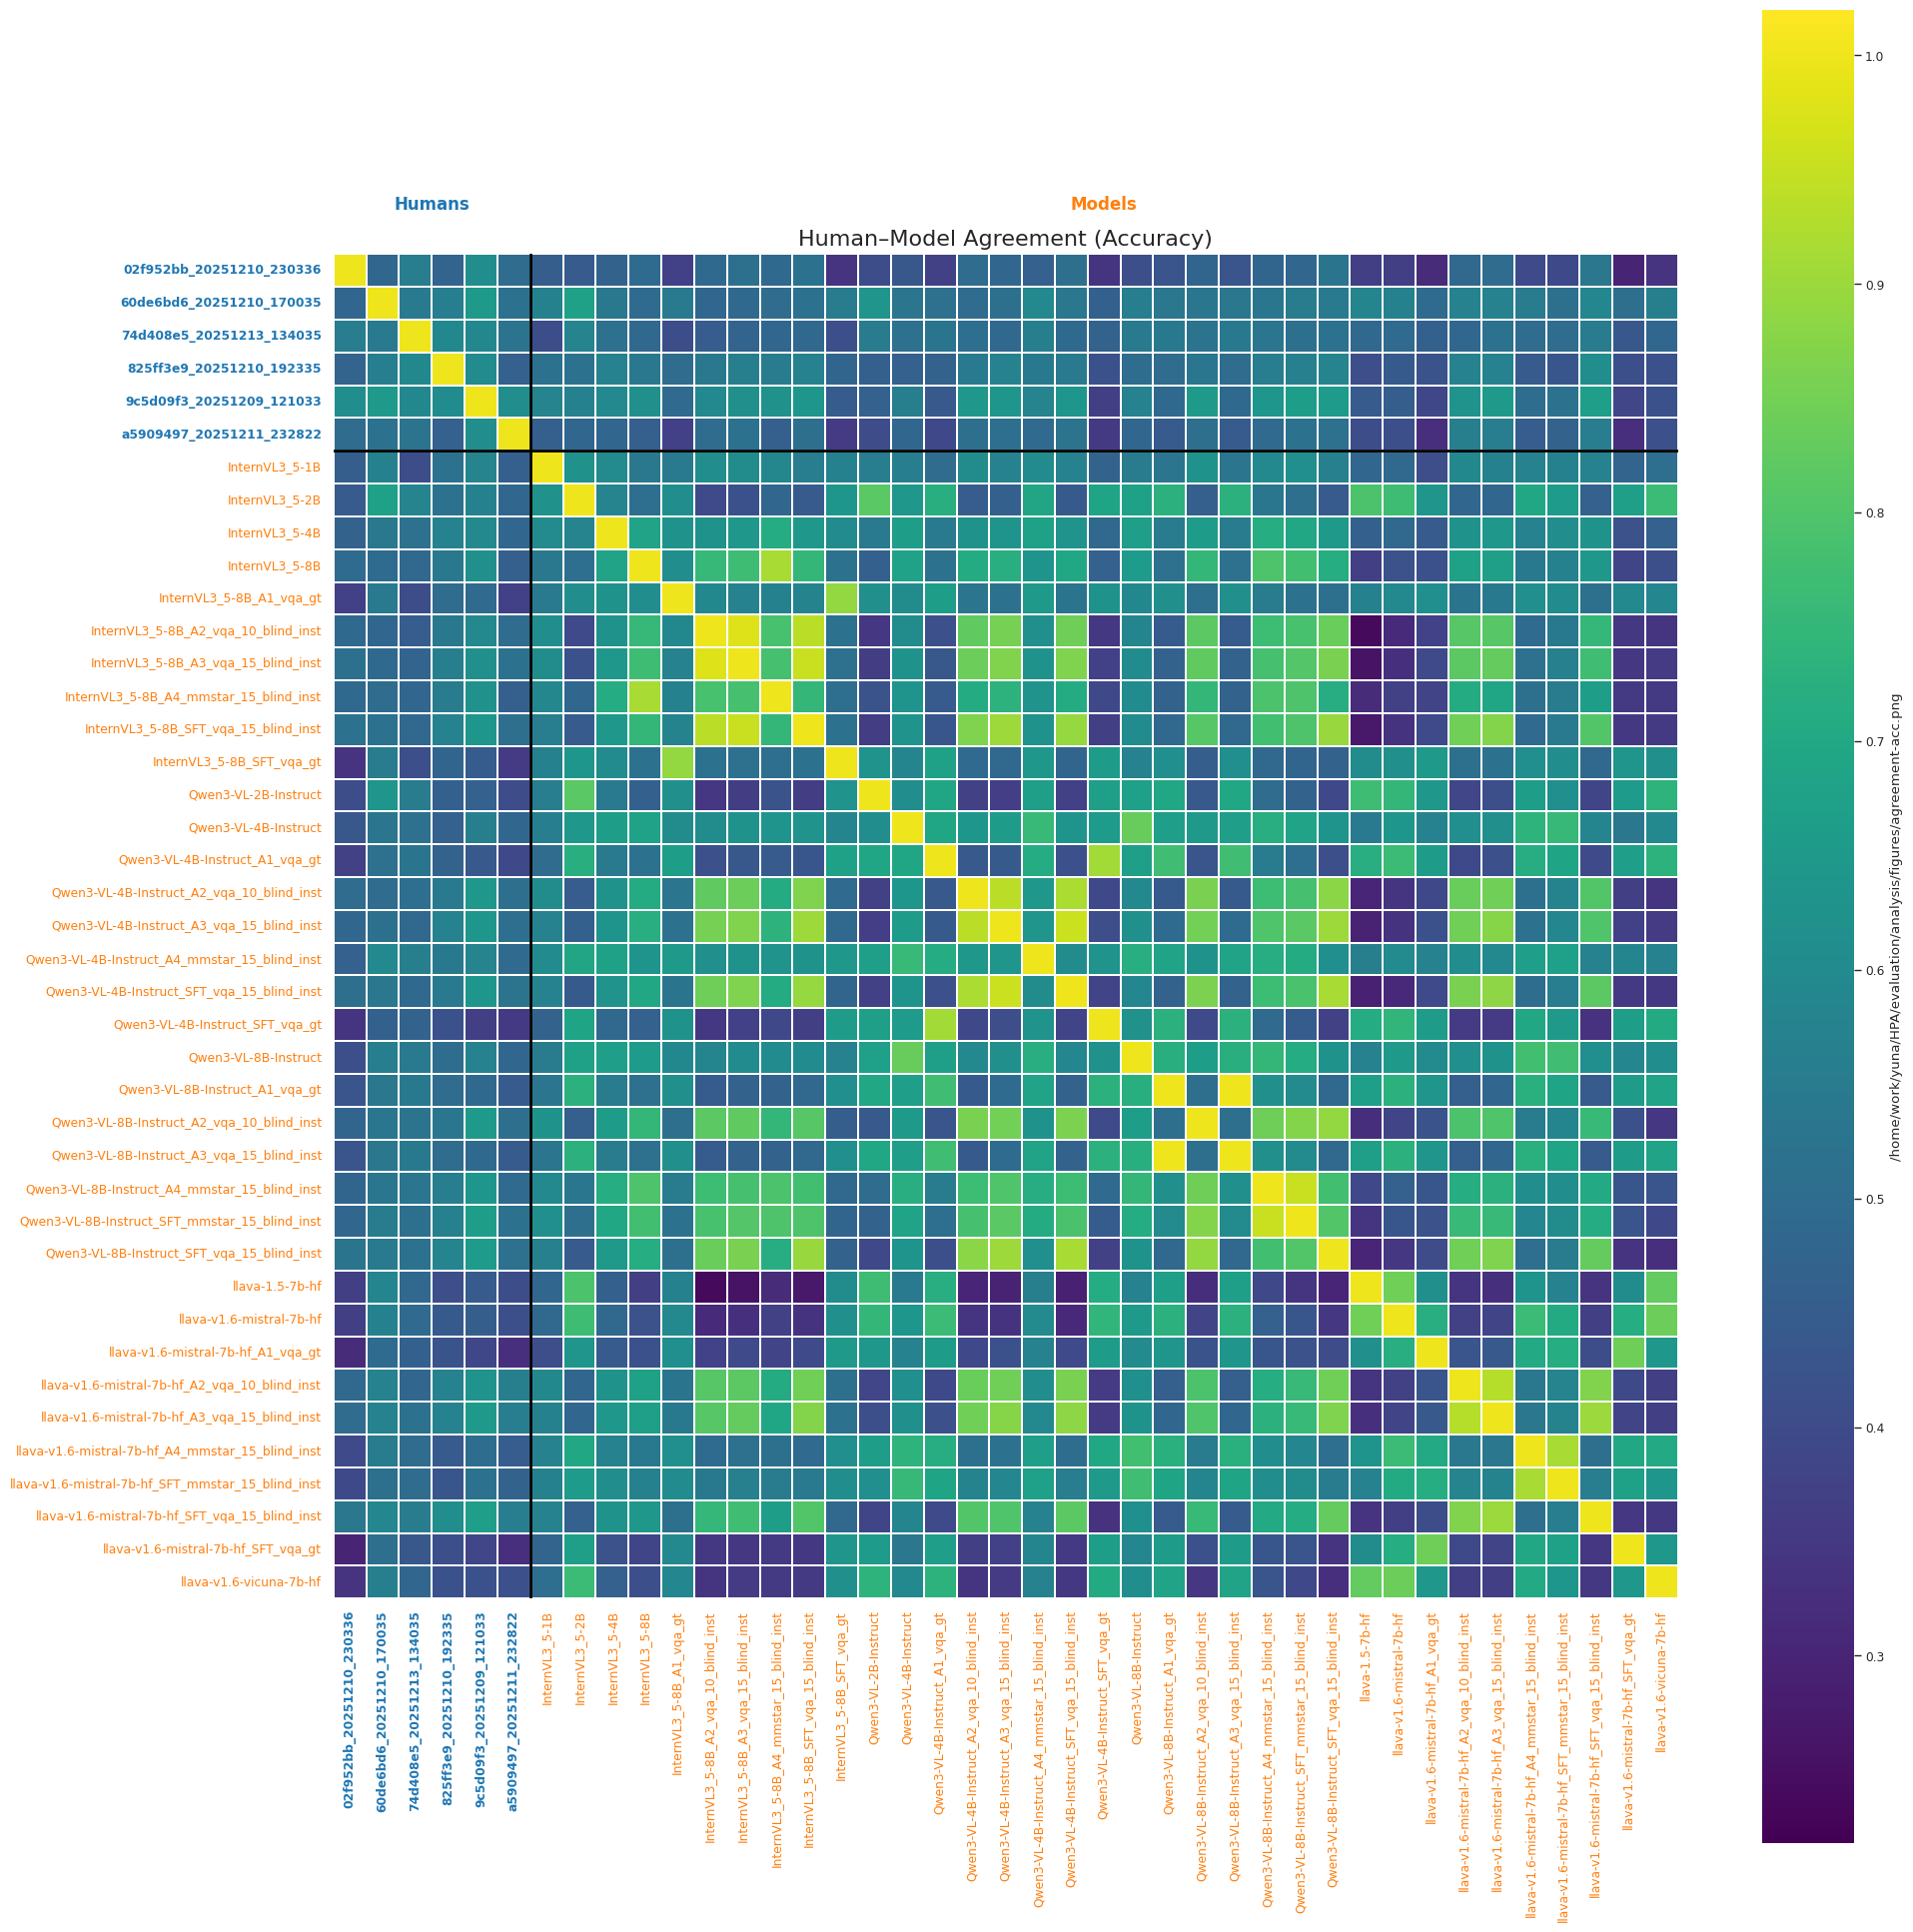

In [ ]:
from utils.corr import get_all_cm, get_agreements, transform_corr_table, plot_unified_agreement_heatmap
from utils.df import result_to_df 

res_HH, res_MM, res_HM  = get_agreements(human_vqa, model_vqa, n_boot=0)  # accuarcy 
corr_mat = get_all_cm(res_HH, res_MM, res_HM )
acc_corr = res_HM['corr_mat'].mean().sort_values().reset_index(name='acc_corr') 
plot_unified_agreement_heatmap(corr_mat, res_HH['corr_mat'].columns, res_MM['corr_mat'].columns, 'Human–Model Agreement (Accuracy)', '/home/work/yuna/HPA/evaluation/analysis/figures/agreement-acc.png') 
acc = pd.concat([result_to_df(res_HH), result_to_df(res_MM), result_to_df(res_HM)]) 


In [ ]:
res_HH['corr_mat'].mean().reset_index().to_csv('./corr-humans-n6.csv')

participant_id
02f952bb_20251210_230336    0.565751
60de6bd6_20251210_170035    0.634863
74d408e5_20251213_134035    0.621355
825ff3e9_20251210_192335    0.620217
9c5d09f3_20251209_121033    0.655683
a5909497_20251211_232822    0.543538
dtype: float64

In [122]:
res_MM['corr_mat'].mean().reset_index().to_csv('./corr-models-toM.csv')

In [118]:
res_HM['corr_mat'].mean().reset_index().to_csv('./corr-models-toH-n6.csv')

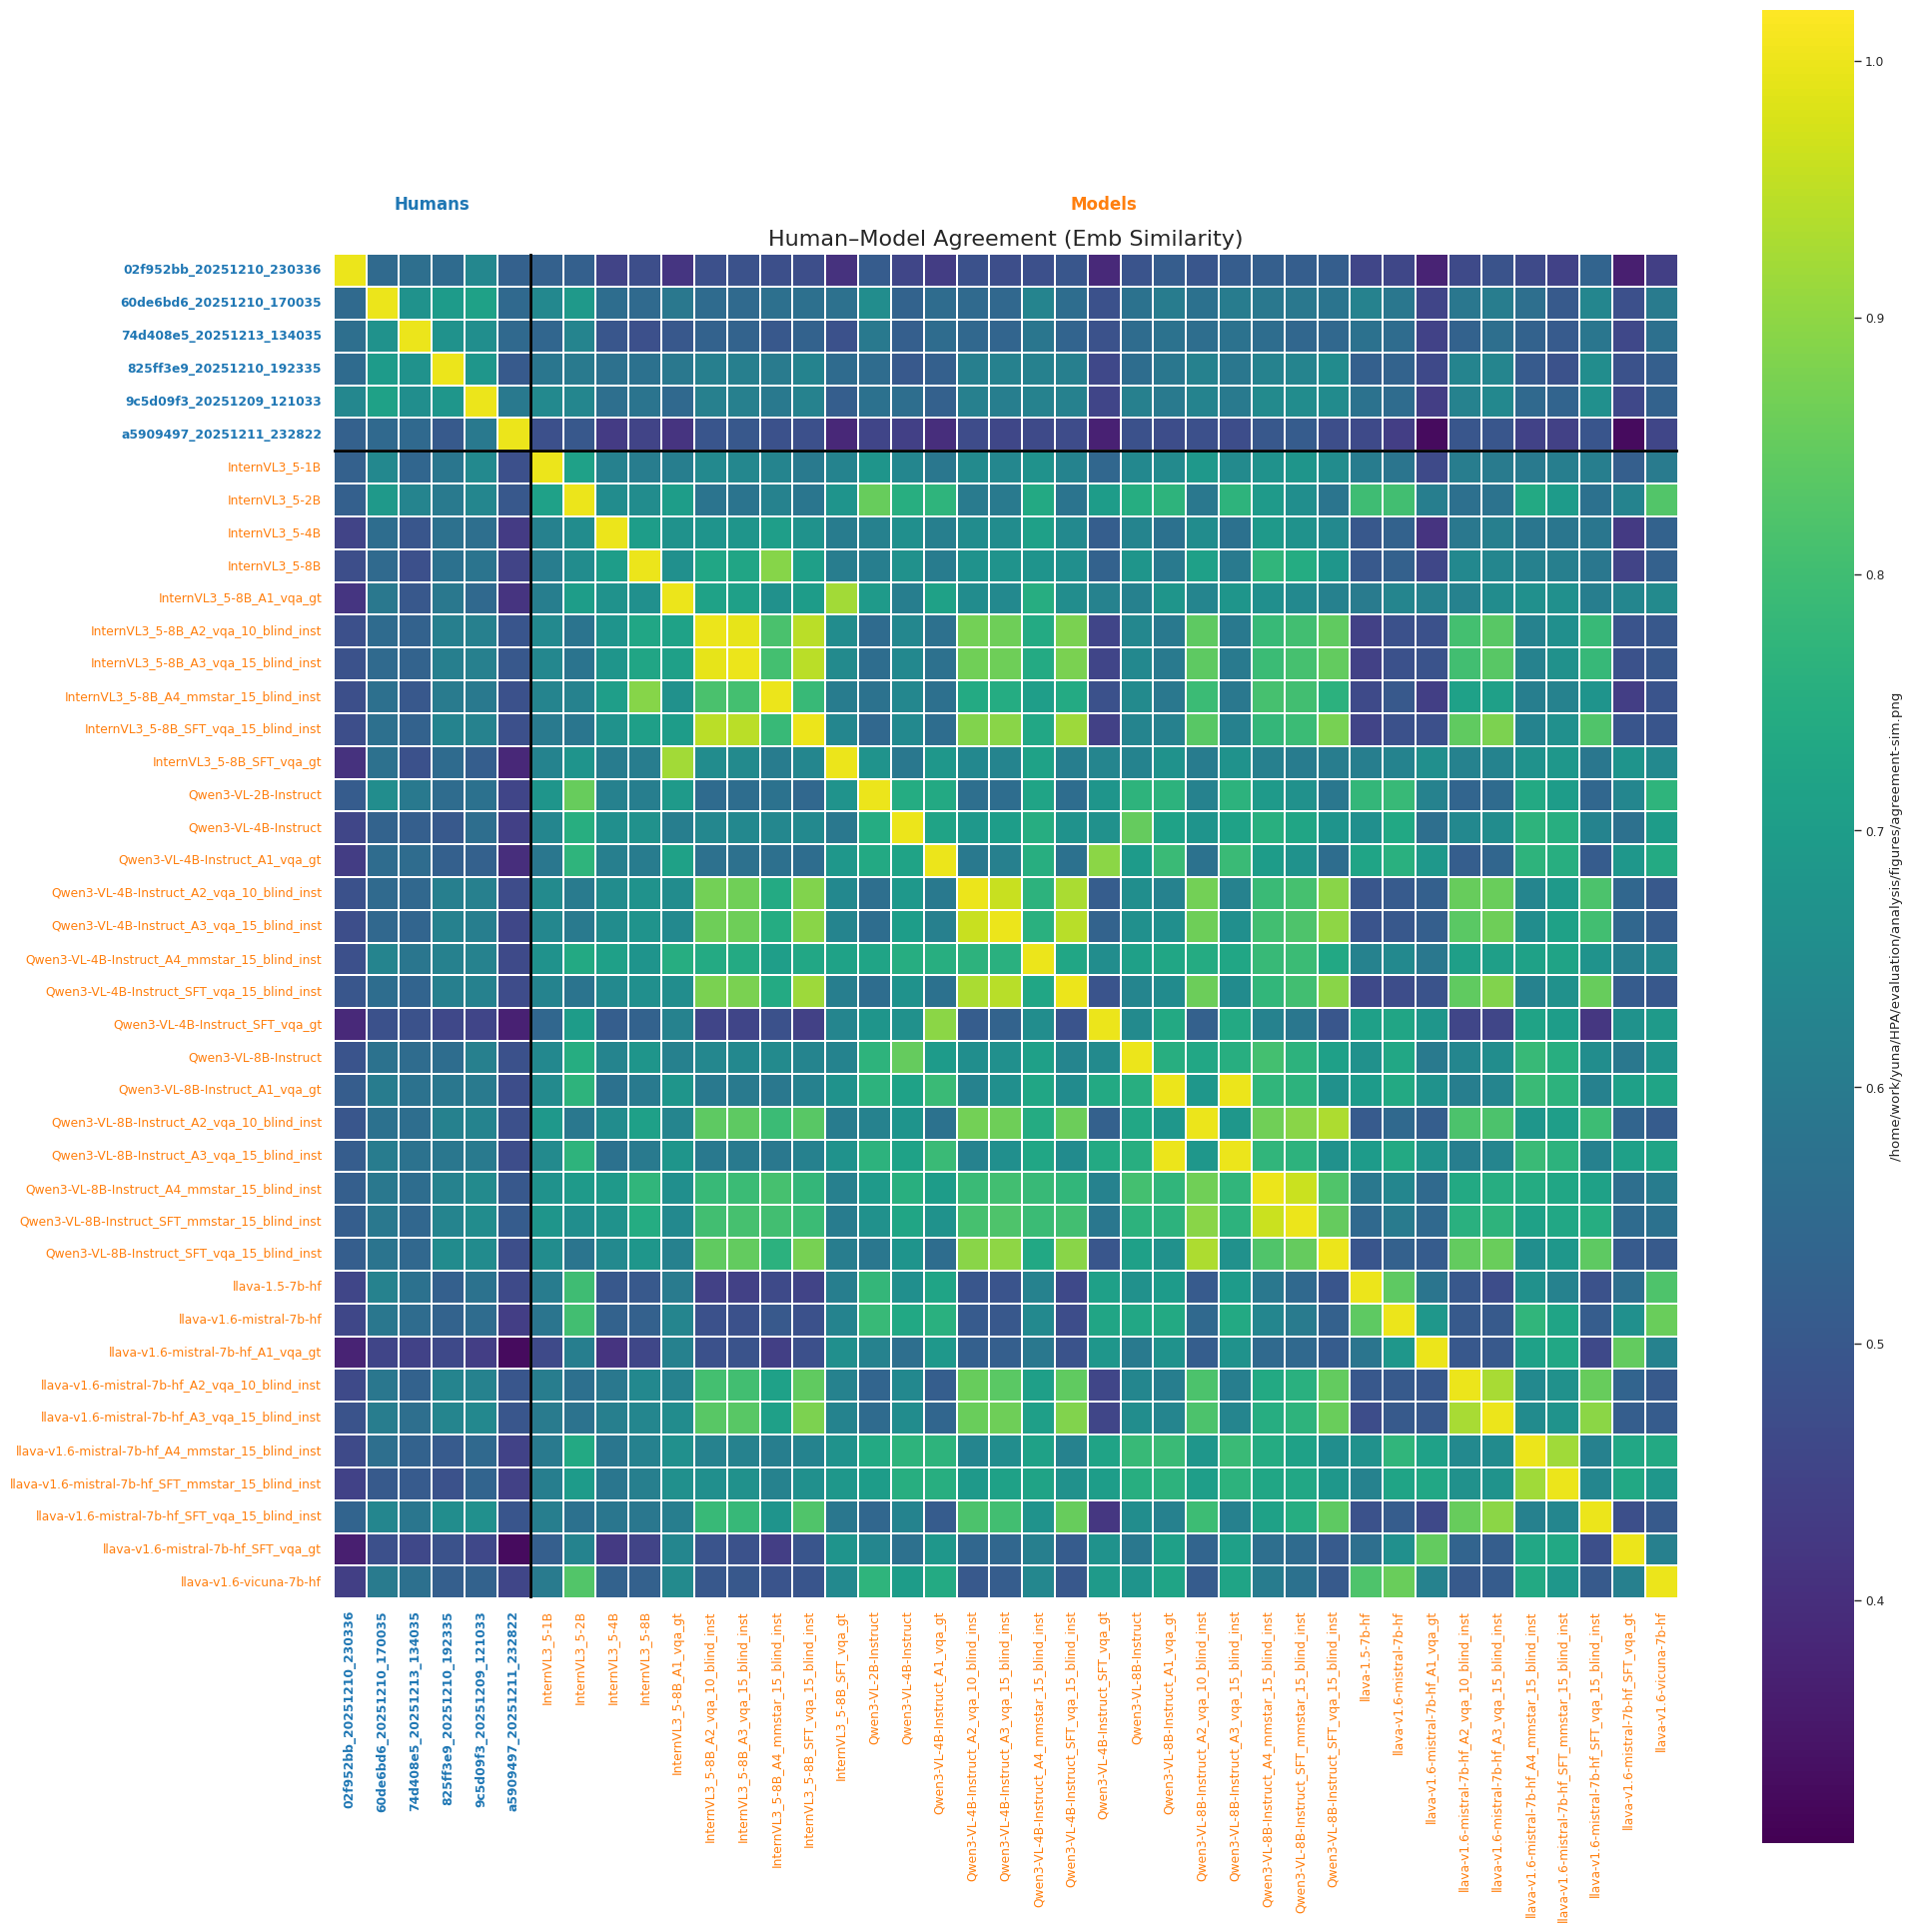

signal,Accuracy $\rho$,Embedding $\rho$
comparison,,
Human–Human,"0.553 [0, 0]","0.611 [0, 0]"
Human–Model,"0.503 [0, 0]","0.536 [0, 0]"
Model–Model,"0.63 [0, 0]","0.69 [0, 0]"


In [111]:
res_HH, res_MM, res_HM  =  get_agreements(human_vqa, model_vqa, 'answer_similarity', n_boot=0) 
corr_mat = get_all_cm(res_HH, res_MM, res_HM ) 
sim_corr = res_HM['corr_mat'].mean().sort_values().reset_index(name='sim_corr') 
acc = pd.concat([acc, result_to_df(res_HH), result_to_df(res_MM), result_to_df(res_HM)])
plot_unified_agreement_heatmap(corr_mat,  res_HH['corr_mat'].columns, res_MM['corr_mat'].columns, 'Human–Model Agreement (Emb Similarity)', '/home/work/yuna/HPA/evaluation/analysis/figures/agreement-sim.png') 
transform_corr_table(acc) # .to_latex('./tables/appendix/3_spearman-interrater-vqa-finetuned.tex', float_format="%.3f")   

In [148]:
# Calculate MG = condition['inst_blind'] - condition[''] within the same model in vqa_5k
mg_df = vqa_5k.pivot_table(
    index='model',
    columns='condition',
    values=['correct', 'answer_similarity'],  # or whatever metric you want to use for MG, e.g. "MG_Acc" or "MG_S"
)

mg_df[("MG_Acc", "")] = (
    mg_df[("correct", "")]
    - mg_df[("correct", "inst blind")]
)

mg_df[("MG_S", "")] = (
    mg_df[("answer_similarity", "")]
    - mg_df[("answer_similarity", "inst blind")]
)
mg_df = mg_df.reset_index()

mg_df[['model', 'MG_Acc', 'MG_S']].to_csv('./5k-vqa-mg.csv')

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


Pearson $r$ = -0.245 ($R^2$ = 0.060) | Spearman $\rho$ = -0.257


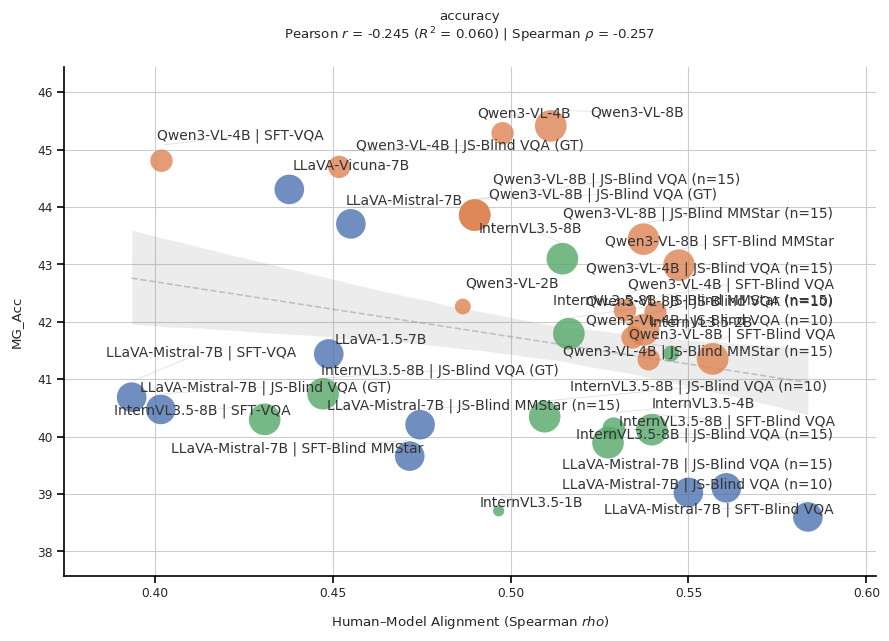

Pearson $r$ = -0.149 ($R^2$ = 0.022) | Spearman $\rho$ = -0.210


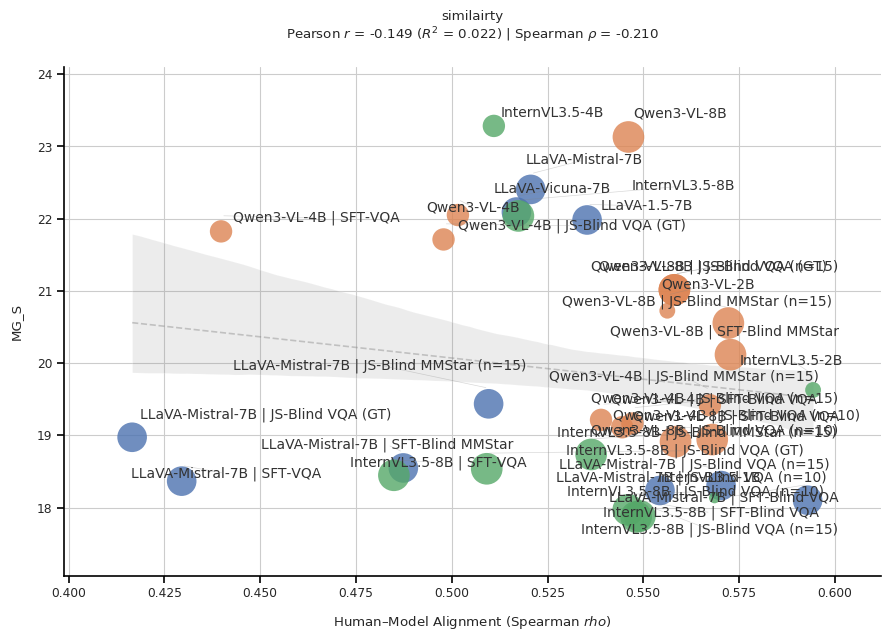

In [ ]:
pcorr['model'] = pcorr['model'].map(MODEL_DISPLAY_MAP)
pd.merge(pcorr, mg_df.reset_index(), on=['model']) 
pcorr= pd.merge(pcorr, mg_df.reset_index(), on=['model']) 
pcorr = pcorr[['model', 'acc_corr', 'sim_corr', 'MG_Acc', 'MG_S']]

pcorr['family'] = pcorr['model'].map(get_family)
pcorr['model_size'] = pcorr['model'].map(parse_size) 

scatterplot(pcorr, x_col='acc_corr', y_col='MG_Acc', title='accuracy') 
scatterplot(pcorr, x_col='sim_corr', y_col='MG_S', title='similairty') 
pcorr.to_csv('./all_models-corr.csv')

In [156]:
from utils.plots import scatterplot, get_family, parse_size  
# from utils.df import aggregate_vqa, model_name_map, calculate_mg  

mg_df.columns = [
    col[0] if isinstance(col, tuple) else col
    for col in mg_df.columns
]
pcorr = pd.merge(acc_corr, sim_corr, on =['model']) 
pcorr 

,model,acc_corr,sim_corr
0,llava-v1.6-mistral-7b-hf_SFT_vqa_gt,0.393473,0.429499
1,llava-v1.6-mistral-7b-hf_A1_vqa_gt,0.401660,0.416567
2,Qwen3-VL-4B-Instruct_SFT_vqa_gt,0.401851,0.439777
3,InternVL3_5-8B_SFT_vqa_gt,0.430859,0.484900
4,llava-v1.6-vicuna-7b-hf,0.437786,0.516886
5,InternVL3_5-8B_A1_vqa_gt,0.447289,0.509137
6,llava-1.5-7b-hf,0.448877,0.535330
7,Qwen3-VL-4B-Instruct_A1_vqa_gt,0.451828,0.497858
8,llava-v1.6-mistral-7b-hf,0.455098,0.520616
9,llava-v1.6-mistral-7b-hf_SFT_mmstar_15_blind_inst,0.471630,0.487363


In [ ]:
import ast 
from utils.score import extract_mc_choice 
df = get_summary(dataset='spubench')
df['spurious_correlation_type'] = df['spurious_correlation_type'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)
df= df.explode('spurious_correlation_type') 
spu= pd.read_json("/home/work/yuna/HPA/dataset/annotation.json").reset_index()
spu['pid'] = spu['index']
df = pd.merge(df, spu, on="pid", how="left", suffixes=("", "_annot"))
df = df.loc[:, ~df.columns.duplicated()]
df["mc_choice"] = df["output"].apply(extract_mc_choice)
df["answer"] = df["answer"].fillna(df["answer_annot"])
df["correct"] = (
    df["mc_choice"].notna()
    & df["answer"].notna()
    & (df["mc_choice"].str.strip().str[0].str.upper()
       == df["answer"].str.upper())
)
df = df.dropna(axis=1, how="all")
df.groupby(['model'])['correct'].mean().reset_index().to_csv('./sputbench.csv', encoding="utf-8-sig")

88


In [ ]:
count_df = df.groupby(['spurious_correlation_type', 'model'])['correct'].count().reset_index(name='count')
valid_pairs = count_df[count_df['count'] > 10][['spurious_correlation_type', 'model']]
filtered_df = df.merge(valid_pairs, on=['spurious_correlation_type', 'model'], how='inner')

In [324]:
df.explode('spurious_correlation_type_annot').pivot_table(index=['model'], 
                                    columns='spurious_correlation_type_annot', 
                                    values='correct').to_csv('./spubench-corr.csv', encoding="utf-8-sig")

KeyError: 'spurious_correlation_type_annot'

In [229]:
with open('/home/work/yuna/HPA/evaluation/scored/humans/human_mc_per_question.json', 'r') as f:
    raw_data = json.load(f) 
human_mc = pd.DataFrame(raw_data)
df = human_mc.rename(columns={'\ufeffquestion_num': 'question_num'}) 
qids = human_mc.pid.unique()   
human_mc['question_id'] = human_mc['pid'].astype('Int64') 
human_mc['model'] = 'Humans'
human_mc['correct'] = human_mc['correct'] * 100
# human_mc= human_mc[human_mc['participant_id']!= '13f54aa2_20251204_125847'] 
trainh = human_mc[human_mc['participant_id'].isin(pids)] 
human_mc = human_mc[~human_mc['participant_id'].isin(pids)] 
len(trainh.participant_id.unique()) , len(human_mc.participant_id.unique()) 

(15, 6)

In [ ]:
model_mc = get_summary('mmstar')
model_mc['question_id'] = model_mc['pid'].astype('Int64') 
model_mc = model_mc.drop_duplicates(subset=['model', 'question_id', 'condition']) 
model_mc['model'] = model_mc['model'].map(MODEL_DISPLAY_MAP)  
blind_model=model_mc[model_mc['condition'] == 'inst blind']
print(model_mc.model.unique(), model_mc.condition.unique()) 
mmstar_blind = pd.concat([blind_model[blind_model['pid'].isin(qids)], human_mc])
mmstar_blind.to_csv('./finetuned-mmstar-subset.csv')
mmstar_blind.groupby(['model']).count()

In [255]:
pt = pd.concat([model_mc,human_mc]).pivot_table(
    index=['model', 'category', 'l2_category', 'question_id'], # , 'output', 'question' 
    values='correct',
    columns='condition',
    aggfunc='mean'
)
pt['Acc_Visual'] = pt['']
pt['Acc_Blind_inst'] = pt['inst blind']
pt['MG_Acc'] = pt[''] - pt['inst blind']
pt['Delta_Inst'] = pt['blind'] - pt['inst blind']
pt = pt.reset_index()
pt.to_csv('./all_mmstar_models-qs-mg.csv')

In [256]:
pt.groupby(['model']).mean(numeric_only=True).drop(columns=['', 'blind', 'inst blind']).to_latex(
            f'./mmstar-mg-finetuned-by-models.tex', float_format="%.1f"
        )

In [260]:
pt[pt['question_id'].isin(qids)].pivot_table(
    index=['model'], 
    values='MG_Acc',
    columns=['category', 'l2_category'],
    aggfunc='mean'
).to_latex(f'./tables/4_mmstar-mg-finetuned-catl2-subset.tex', float_format="%.1f")  

In [261]:
pt[pt['question_id'].isin(qids)].pivot_table(
    index=['model'], 
    values='MG_Acc',
    columns=['category'],
    aggfunc='mean'
).to_latex(f'./tables/4_mmstar-mg-finetuned-cat-subset.tex', float_format="%.1f")  

In [311]:
from utils.corr import plot_unified_agreement_heatmap  # get_agreements
from utils.ac1 import interrater_agreement_ac1 

metrics='correct' 
n_boot=200 
human_acc = human_mc.drop_duplicates(subset=['question_id', 'participant_id']).pivot(
        index=["category", "l2_category", "question_id"],
        columns="participant_id",
        values=metrics
    )
model_acc = blind_model.pivot_table( # .drop_duplicates(subset=['model', 'question_id'])
    index=["category", "l2_category", "question_id"], 
    columns="model",
    values=metrics, 
    aggfunc='mean'
) 
answers_pivot = human_acc.join(model_acc, how="inner").reset_index() 
humans = human_acc.columns
models = model_acc.columns

In [314]:
category_corr = []
for category in answers_pivot.category.unique():  

    for l2_category in answers_pivot.l2_category.unique():  
        res = interrater_agreement_ac1(
            answers_pivot[(answers_pivot['category'] == category) &(answers_pivot['l2_category'] ==  l2_category)],
            grp1=humans,
            grp2=models,
            n_boot=0,
            ) 
        res['category'] = category 
        res['l2_category'] = l2_category 
        category_corr.append(res)
category_corr = pd.DataFrame(category_corr)


In [322]:
category_corr.dropna(subset=['mean_r']).to_csv(f"./tables/appendix/mmstar-ac1-l2category.csv", encoding="utf-8-sig") 

In [ ]:
category_corr.to_latex(f"./tables/appendix/mmstar-ac1-category.tex", float_format="%.1f")  

In [303]:
model_corr = [] 
for i, cc in category_corr.iterrows(): 
    corr_mat=cc['corr_mat'].T.reset_index().melt(id_vars=['model'], var_name='subj', value_name='corr')    
    corr_mat['category'] = cc['category']
    model_corr.append(corr_mat) 
model_corr= pd.concat(model_corr)
model_corr.dropna()

,model,subj,corr,category
0,InternVL3.5‑1B,02f952bb_20251210_230336,0.448276,coarse perception
1,InternVL3.5‑2B,02f952bb_20251210_230336,0.623698,coarse perception
2,InternVL3.5‑4B,02f952bb_20251210_230336,0.490885,coarse perception
3,InternVL3.5‑8B,02f952bb_20251210_230336,0.480916,coarse perception
4,InternVL3.5‑8B | JS‑Blind MMStar (n=15),02f952bb_20251210_230336,0.540230,coarse perception
...,...,...,...,...
205,Qwen3‑VL‑8B | JS‑Blind VQA (GT),a5909497_20251211_232822,-0.090090,logical reasoning
206,Qwen3‑VL‑8B | JS‑Blind VQA (n=10),a5909497_20251211_232822,0.000000,logical reasoning
207,Qwen3‑VL‑8B | JS‑Blind VQA (n=15),a5909497_20251211_232822,-0.090090,logical reasoning
208,Qwen3‑VL‑8B | SFT‑Blind MMStar,a5909497_20251211_232822,0.141844,logical reasoning


In [323]:
model_corr.groupby(['model', 'category'])['corr'].mean().reset_index().to_csv('./corr-mmstar-MH-cat.csv', encoding="utf-8-sig")